# Курсовая работа: EDA данных химических соединений

Цель раздела — изучить структуру данных, целевые переменные `IC50, mM`, `CC50, mM`, `SI`, пропуски, выбросы, корреляции и возможные признаки, полезные для последующих моделей.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
TARGET_COLUMNS = ['IC50, mM', 'CC50, mM', 'SI']
DATA_PATH = Path('../data/drug_activity.csv')
RESULTS_DIR = Path('../results')
FIG_DIR = Path('../reports/figures')
RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print('Размер данных:', df.shape)
display(df.head())


Размер данных: (1001, 213)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


## Общая информация и типы признаков


In [3]:
display(df.info())
display(df.describe().T.head(20))
df.describe().T.to_csv(RESULTS_DIR / 'eda_describe.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


None

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089177,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000
MaxAbsEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
MaxEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
MinAbsEStateIndex,1001.0,0.180681,0.168710,0.000039,0.051073,0.124606,0.291020,1.374614
MinEStateIndex,1001.0,-0.967237,1.588036,-6.992796,-1.334487,-0.419485,0.061754,1.374614
qed,1001.0,0.580412,0.212230,0.059567,0.442842,0.634981,0.742483,0.947265
SPS,1001.0,29.487989,12.742749,9.416667,18.486486,29.290323,38.750000,60.272727
MolWt,1001.0,348.262234,126.946370,110.156000,264.321000,315.457000,409.283000,904.777000


## Анализ пропусков

Пропуски могут возникать из-за невозможности расчёта отдельных химических дескрипторов или ошибок при подготовке таблицы.


In [4]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_share': df.isna().mean()
}).sort_values('missing_share', ascending=False)
display(missing.head(20))
missing.to_csv(RESULTS_DIR / 'eda_missing.csv')


,missing_count,missing_share
MinAbsPartialCharge,3,0.002997
MaxPartialCharge,3,0.002997
MinPartialCharge,3,0.002997
MaxAbsPartialCharge,3,0.002997
BCUT2D_MWHI,3,0.002997
BCUT2D_MRLOW,3,0.002997
BCUT2D_MRHI,3,0.002997
BCUT2D_LOGPLOW,3,0.002997
BCUT2D_LOGPHI,3,0.002997
BCUT2D_CHGLO,3,0.002997


## Распределения целевых переменных

Биологические показатели часто имеют асимметричные распределения и выбросы. Поэтому дополнительно смотрим распределения в масштабе `log1p`.


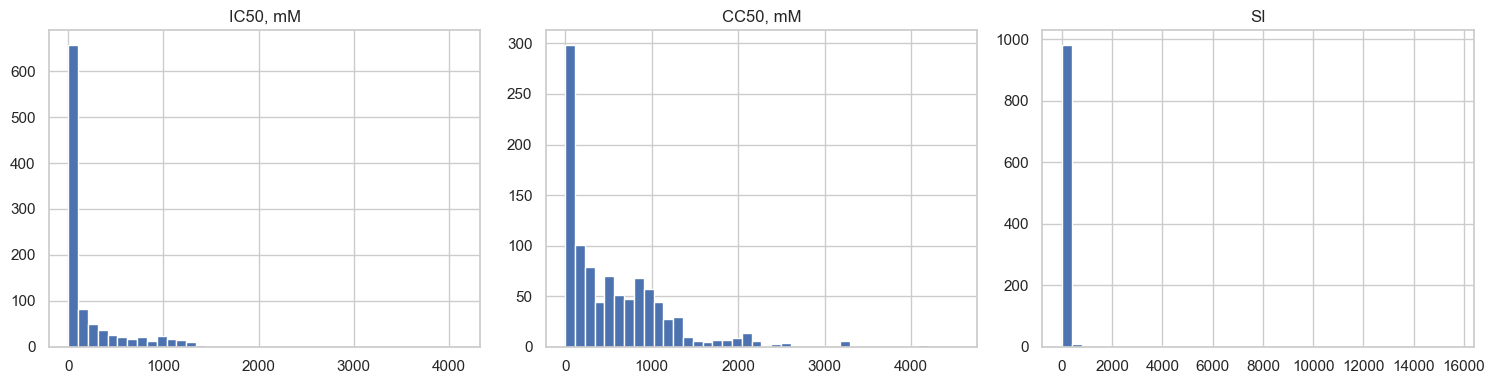

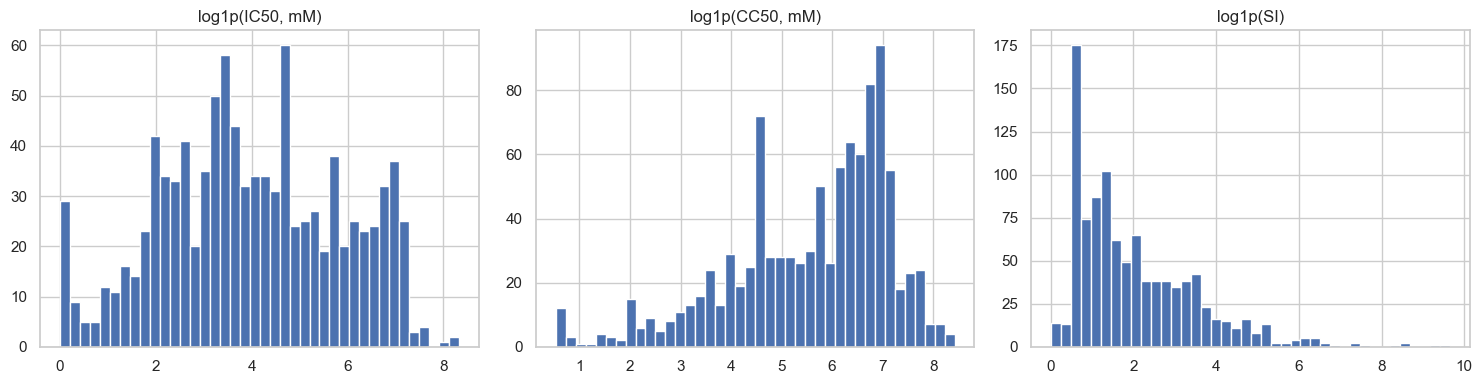

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, TARGET_COLUMNS):
    ax.hist(df[col].dropna(), bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG_DIR / 'target_distributions_raw.png', dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, TARGET_COLUMNS):
    ax.hist(np.log1p(df[col].dropna()), bins=40)
    ax.set_title(f'log1p({col})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'target_distributions_log.png', dpi=160)
plt.show()


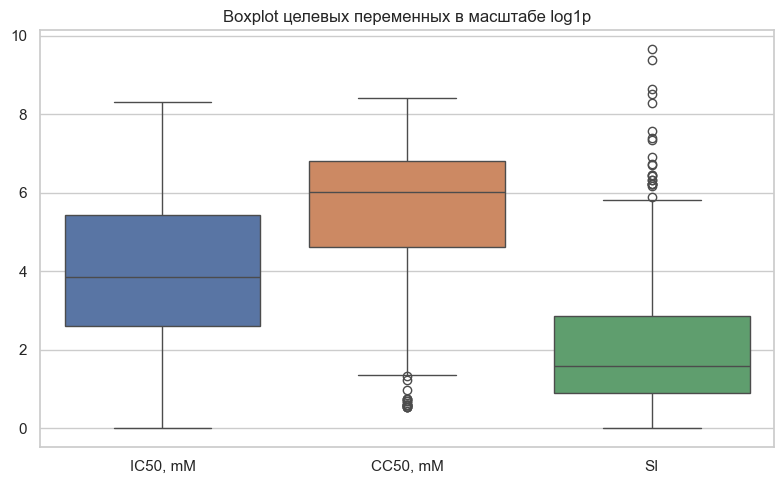

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=np.log1p(df[TARGET_COLUMNS]))
plt.title('Boxplot целевых переменных в масштабе log1p')
plt.tight_layout()
plt.savefig(FIG_DIR / 'target_boxplots_log.png', dpi=160)
plt.show()


## Корреляционный анализ

Так как `SI` рассчитывается на основе `IC50` и `CC50`, при построении моделей все три целевые переменные будут удаляться из признакового пространства, чтобы избежать утечки данных.


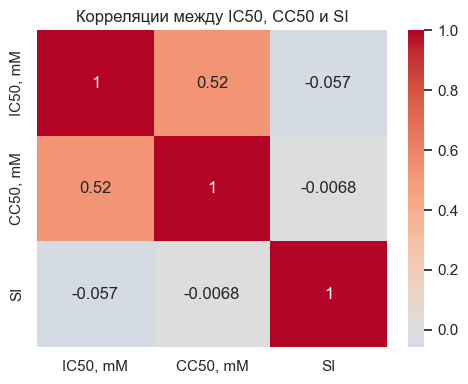

In [7]:
corr = df.corr(numeric_only=True)
corr.to_csv(RESULTS_DIR / 'eda_correlation_matrix.csv')

plt.figure(figsize=(5, 4))
sns.heatmap(corr.loc[TARGET_COLUMNS, TARGET_COLUMNS], annot=True, cmap='coolwarm', center=0)
plt.title('Корреляции между IC50, CC50 и SI')
plt.tight_layout()
plt.savefig(FIG_DIR / 'target_correlation.png', dpi=160)
plt.show()


,target,feature,abs_corr,corr
0,"IC50, mM",VSA_EState4,0.274203,-0.274203
1,"IC50, mM",Chi2n,0.257058,-0.257058
2,"IC50, mM",PEOE_VSA7,0.255988,-0.255988
3,"IC50, mM",Chi2v,0.249164,-0.249164
4,"IC50, mM",fr_Ar_NH,0.245511,0.245511
5,"IC50, mM",fr_Nhpyrrole,0.245511,0.245511
6,"IC50, mM",Chi4v,0.243600,-0.243600
7,"IC50, mM",Chi4n,0.243497,-0.243497
8,"IC50, mM",Chi3n,0.239741,-0.239741
9,"IC50, mM",Chi3v,0.237759,-0.237759


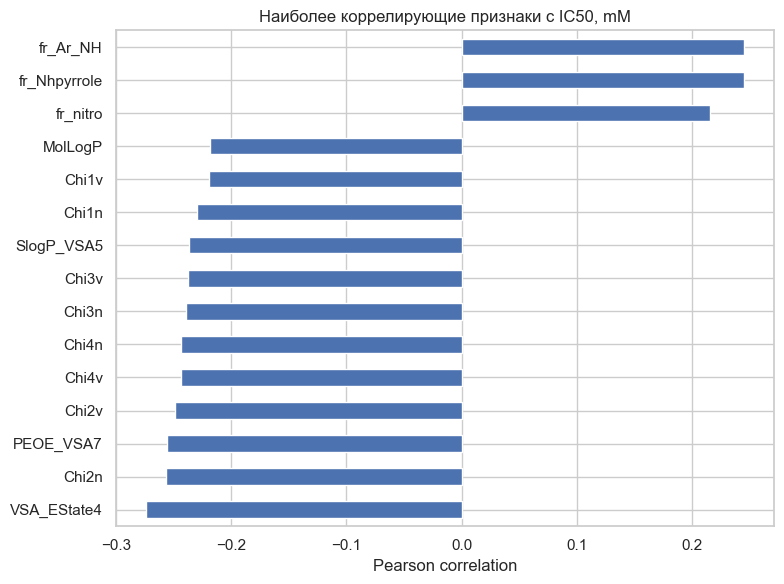

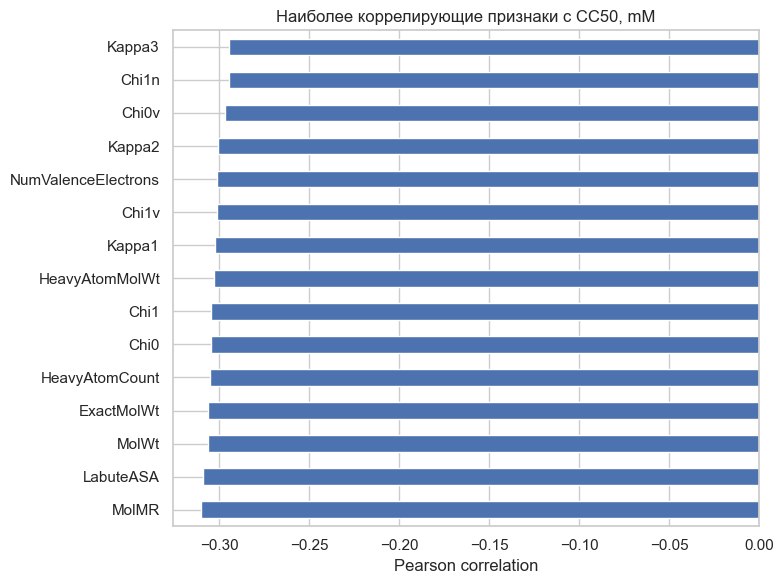

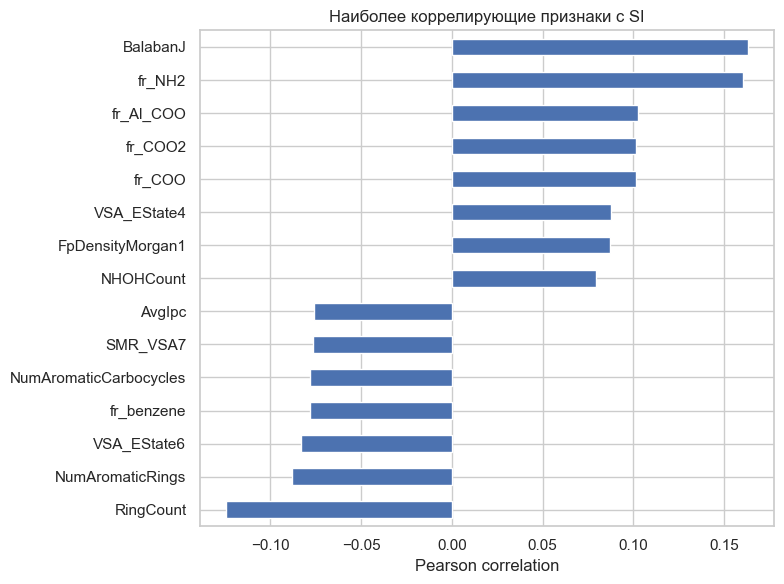

In [8]:
target_corr = corr[TARGET_COLUMNS].drop(index=TARGET_COLUMNS, errors='ignore')
top_rows = []
for target in TARGET_COLUMNS:
    top = target_corr[target].abs().sort_values(ascending=False).head(15)
    for feature, value in top.items():
        top_rows.append({
            'target': target,
            'feature': feature,
            'abs_corr': value,
            'corr': corr.loc[feature, target]
        })

top_corr_df = pd.DataFrame(top_rows)
display(top_corr_df)
top_corr_df.to_csv(RESULTS_DIR / 'eda_top_target_correlations.csv', index=False)

for target in TARGET_COLUMNS:
    top = target_corr[target].sort_values(key=lambda s: s.abs(), ascending=False).head(15).sort_values()
    plt.figure(figsize=(8, 6))
    top.plot(kind='barh')
    plt.title(f'Наиболее коррелирующие признаки с {target}')
    plt.xlabel('Pearson correlation')
    plt.tight_layout()
    safe = target.replace(', mM', '').lower()
    plt.savefig(FIG_DIR / f'top_corr_{safe}.png', dpi=160)
    plt.show()


## Сильно коррелирующие признаки

Сильно коррелирующие дескрипторы могут быть избыточными. В моделях далее применяется `VarianceThreshold`, а регуляризованные и ансамблевые модели дополнительно помогают снизить влияние шумовых признаков.


In [9]:
feature_cols = [c for c in df.columns if c not in TARGET_COLUMNS]
feature_corr = corr.loc[feature_cols, feature_cols].abs()
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False).head(50).reset_index()
high_pairs.columns = ['feature_1', 'feature_2', 'abs_corr']
display(high_pairs.head(20))
high_pairs.to_csv(RESULTS_DIR / 'eda_highly_correlated_feature_pairs.csv', index=False)


,feature_1,feature_2,abs_corr
0,NumAromaticCarbocycles,fr_benzene,1.000000
1,MaxAbsEStateIndex,MaxEStateIndex,1.000000
2,fr_COO,fr_COO2,1.000000
3,fr_Ar_NH,fr_Nhpyrrole,1.000000
4,fr_phenol,fr_phenol_noOrthoHbond,1.000000
5,MolWt,ExactMolWt,0.999999
6,Chi1,HeavyAtomCount,0.998742
7,MolWt,HeavyAtomMolWt,0.996850
8,HeavyAtomMolWt,ExactMolWt,0.996821
9,Chi0,HeavyAtomCount,0.995957


## Выводы EDA

1. Данные состоят из числовых химических дескрипторов и трёх целевых показателей эффективности.
2. Целевые переменные имеют выбросы и асимметричные распределения, поэтому для части моделей регрессии полезно использовать логарифмирование целевой переменной.
3. `SI` связан с `IC50` и `CC50`, поэтому эти три колонки нельзя использовать как признаки при предсказании друг друга.
4. Для дальнейшего моделирования используются медианное заполнение пропусков, удаление константных признаков, масштабирование для линейных моделей/SVM и сравнение нескольких алгоритмов.
